In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [27]:
columns = (
    ["unit_number", "time_in_cycles", "op_setting_1", "op_setting_2", "op_setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)
 
train = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None, names=columns)
test = pd.read_csv("test_FD001.txt", sep=r"\s+", header=None, names=columns)
rul_test = pd.read_csv("RUL_FD001.txt", header=None, names=["RUL"])

In [28]:
drop_columns = ["sensor_1", "sensor_5", "sensor_6", "sensor_10",
                 "sensor_16", "sensor_18", "sensor_19"]
 
train = train.drop(columns=drop_columns)
test = test.drop(columns=drop_columns)
 
sensor_columns = [c for c in train.columns if c.startswith("sensor")]
feature_columns = ["op_setting_1", "op_setting_2", "op_setting_3"] + sensor_columns
n_features = len(feature_columns)

In [29]:
max_cycle = train.groupby("unit_number")["time_in_cycles"].transform("max")
train["RUL"] = (max_cycle - train["time_in_cycles"]).clip(upper=125)
 

In [30]:
scaler = StandardScaler()
train[feature_columns] = scaler.fit_transform(train[feature_columns])
test[feature_columns] = scaler.transform(test[feature_columns])

In [31]:
sequence_length = 30
 
 
def create_sequences(data, seq_length, feature_cols):
    X, y, groups = [], [], []
    for engine_id in data["unit_number"].unique():
        engine_data = data[data["unit_number"] == engine_id]
        features = engine_data[feature_cols].values
        labels = engine_data["RUL"].values
        for i in range(len(engine_data) - seq_length + 1):
            X.append(features[i:i + seq_length])
            y.append(labels[i + seq_length - 1])
            groups.append(engine_id)
    return np.array(X), np.array(y), np.array(groups)
 
 
X, y, groups = create_sequences(train, sequence_length, feature_columns)
print("X shape:", X.shape, " y shape:", y.shape)

X shape: (17731, 30, 17)  y shape: (17731,)


In [32]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter.split(X, y, groups=groups))
X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]
print("X_train:", X_train.shape, " X_val:", X_val.shape)
 

X_train: (14241, 30, 17)  X_val: (3490, 30, 17)


In [33]:
def pad_sequence(seq, seq_length, n_feats):
    if len(seq) >= seq_length:
        return seq[-seq_length:]
    pad = np.zeros((seq_length - len(seq), n_feats))
    return np.vstack([pad, seq])
 
 
X_test = []
for unit in test["unit_number"].unique():
    engine = test[test["unit_number"] == unit]
    sequence = engine[feature_columns].values
    X_test.append(pad_sequence(sequence, sequence_length, n_features))
X_test = np.array(X_test)
print("X_test:", X_test.shape)
 
y_test_true = rul_test["RUL"].values.clip(max=125)

X_test: (100, 30, 17)


c:\machinery presiction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,433 (509.50 KB)

 Trainable params: 130,433 (509.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 37.3190 - mae: 37.8162 - val_loss: 20.3953 - val_mae: 20.8910
Epoch 2/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 20.6906 - mae: 21.1845 - val_loss: 18.2217 - val_mae: 18.7141
Epoch 3/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 15.8529 - mae: 16.3429 - val_loss: 10.5880 - val_mae: 11.0718
Epoch 4/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 12.5283 - mae: 13.0119 - val_loss: 9.8427 - val_mae: 10.3325
Epoch 5/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 11.3828 - mae: 11.8631 - val_loss: 10.5199 - val_mae: 10.9714
Epoch 6/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 9.8945 - mae: 10.3708 - val_loss: 11.6055 - val_mae: 12.0947
Epoch 7/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 9.0678 - mae: 9.5398 - val_loss: 8.6647 - val_mae: 9.1513
Epoch 8/100
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 9.3358 - mae: 9.8077 - val_loss: 8.2429 - val_mae: 8.7321
Epoch 9/100
223/22

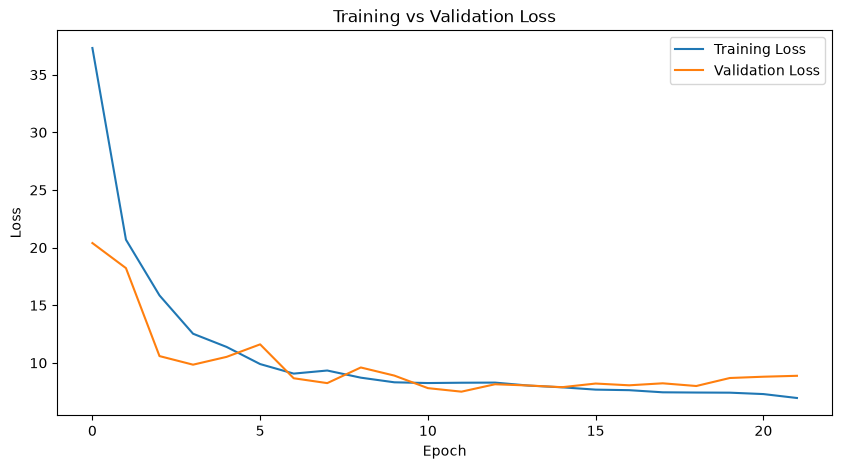

In [34]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(sequence_length, n_features)),
    Dropout(0.3),
    LSTM(64),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1),
])
 
model.compile(optimizer="adam", loss="huber", metrics=["mae"])
model.summary()
 
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
 
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
)
 
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001B4A5243880> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
MAE : 11.34
RMSE: 16.31


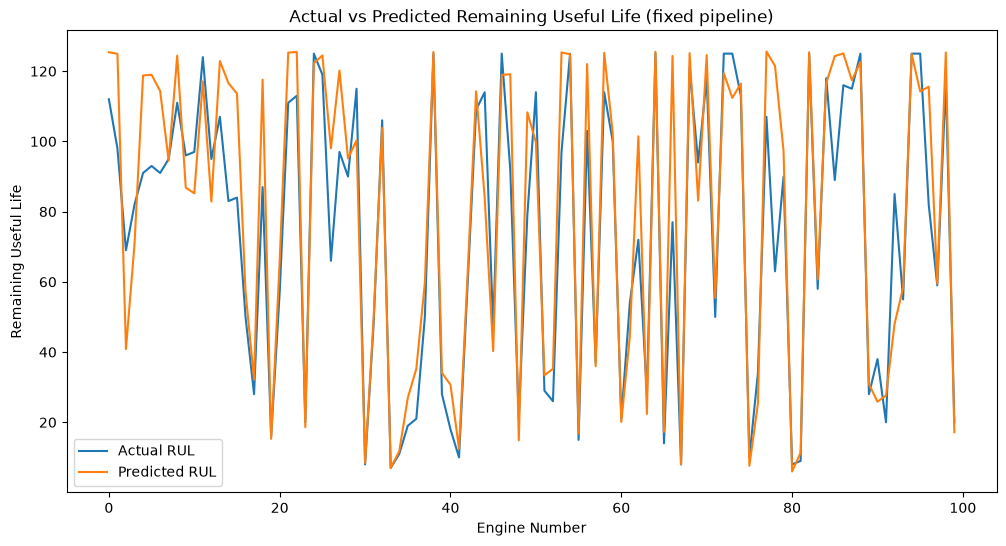

In [35]:
y_pred = model.predict(X_test).flatten()
 
mae = mean_absolute_error(y_test_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_true, y_pred))
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
 
plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label="Actual RUL")
plt.plot(y_pred, label="Predicted RUL")
plt.xlabel("Engine Number")
plt.ylabel("Remaining Useful Life")
plt.title("Actual vs Predicted Remaining Useful Life (fixed pipeline)")
plt.legend()
plt.show()

In [36]:
model.save("lstm_rul_model.keras")
model.save_weights("lstm_rul_model.weights.h5")
import joblib
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")  # save so inference matches training exactly
 
print(f"Saved model expects input shape: (None, {sequence_length}, {n_features})")
print("Architecture for app.py reference:")
model.summary()

Saved model expects input shape: (None, 30, 17)
Architecture for app.py reference:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,301 (1.49 MB)

 Trainable params: 130,433 (509.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 260,868 (1019.02 KB)